     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
3         11.420         20.38           77.58      386.1          0.14250   
416        9.405         21.70           59.60      271.2          0.10440   
181       21.090         26.57          142.70     1311.0          0.11410   
193       12.340         26.86           81.15      477.4          0.10340   
341        9.606         16.84           61.64      280.5          0.08481   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
3             0.28390         0.24140              0.10520         0.2597   
416           0.06159         0.02047              0.01257         0.2025   
181           0.28320         0.24870              0.14960         0.2395   
193           0.13530         0.10850              0.04562         0.1943   
341           0.09228         0.08422              0.02292         0.2036   

     mean fractal dimension  ...  worst texture  worst perimeter  wo

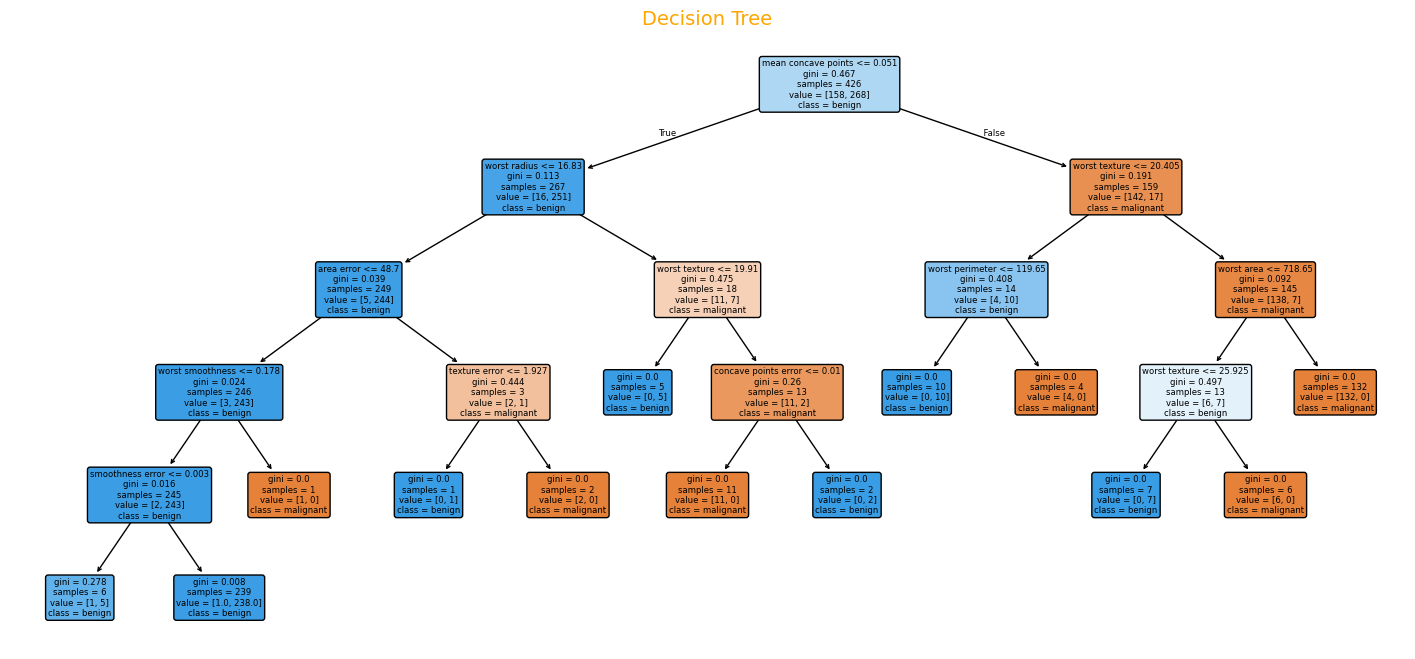

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print(df.sample(5))

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\n", classification_report(y_test, y_pred))

plt.figure(figsize=(18,8))
plot_tree(clf,
          feature_names=X.columns,
          class_names=data.target_names,
          filled=True,
          node_ids=False,
          rounded=True)
plt.title("Decision Tree", fontsize=14, color="orange")
plt.show()
